# **Sentiment Analysis Project**

## Data Loading

In [24]:
import pandas as pd

df = pd.read_csv('Twitter_Data.csv')

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


## Data Exploration

In [25]:
df.shape

(162980, 2)

## Missing Value Handling

In [26]:
df.isnull().sum()

,0
clean_text,4
category,7


In [27]:
df.dropna(inplace=True)

In [28]:
df.isnull().sum()

,0
clean_text,0
category,0


## Sentiment Distribution

In [29]:
df['category'].value_counts()

,count
category,
1.0,72249
0.0,55211
-1.0,35509


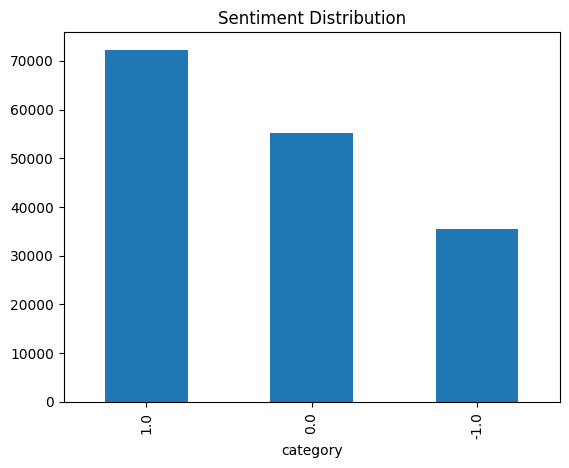

In [30]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.show()

## Feature Engineering (TF-IDF)

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

y = df['category']

## Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Model Building (Naive Bayes)

In [33]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

## Sentiment Prediction

In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7374363379763147


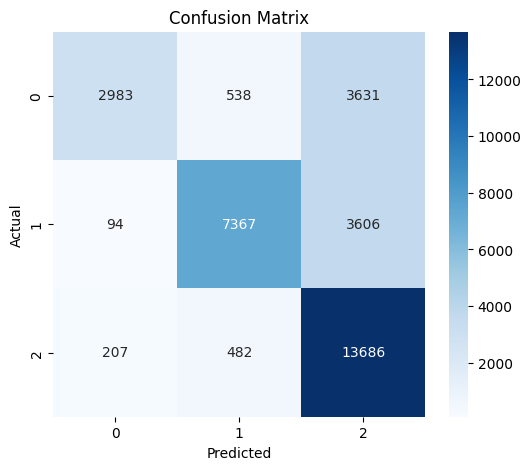

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Custom Sentiment Testing

In [37]:
sample_text = ["I hate this product"]

sample_vector = tfidf.transform(sample_text)

prediction = model.predict(sample_vector)

print(prediction)

[-1.]
